In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

import joblib

In [2]:
df = pd.read_csv("cleaned_data/mobility_cleaned.csv")

In [3]:
df.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low


In [4]:
    df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               5000 non-null   str    
 1   Latitude                5000 non-null   float64
 2   Longitude               5000 non-null   float64
 3   Vehicle_Count           5000 non-null   int64  
 4   Traffic_Speed_kmh       5000 non-null   float64
 5   Road_Occupancy_%        5000 non-null   float64
 6   Traffic_Light_State     5000 non-null   str    
 7   Weather_Condition       5000 non-null   str    
 8   Accident_Report         5000 non-null   int64  
 9   Sentiment_Score         5000 non-null   float64
 10  Ride_Sharing_Demand     5000 non-null   int64  
 11  Parking_Availability    5000 non-null   int64  
 12  Emission_Levels_g_km    5000 non-null   float64
 13  Energy_Consumption_L_h  5000 non-null   float64
 14  Traffic_Condition       5000 non-null   str    
dty

In [5]:
df["Traffic_Condition"].value_counts()

Traffic_Condition
High      3166
Medium    1475
Low        359
Name: count, dtype: int64

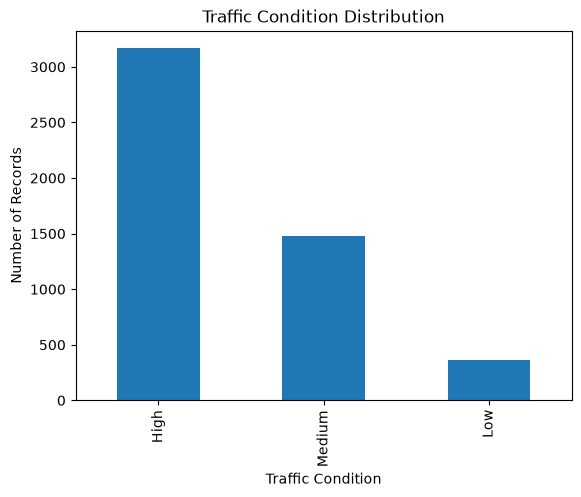

In [6]:
df["Traffic_Condition"].value_counts().plot(kind="bar")

plt.title("Traffic Condition Distribution")
plt.xlabel("Traffic Condition")
plt.ylabel("Number of Records")
plt.show()

In [7]:
X = df.drop("Traffic_Condition", axis=1)
y = df["Traffic_Condition"]

In [8]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day
df["Month"] = df["Timestamp"].dt.month
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

In [9]:
df = df.drop("Timestamp", axis=1)

In [10]:
X = df.drop("Traffic_Condition", axis=1)

X = pd.get_dummies(X, drop_first=True)

y = df["Traffic_Condition"]

In [11]:
X.head()

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Hour,Day,Month,DayOfWeek,Traffic_Light_State_Red,Traffic_Light_State_Yellow,Weather_Condition_Fog,Weather_Condition_Rain,Weather_Condition_Snow
0,40.842275,-73.703149,205,49.893435,82.652780,0,-0.609199,2,45,450.760055,19.574337,0,1,3,4,False,True,False,False,False
1,40.831119,-73.987354,202,22.383965,45.829298,0,0.965442,16,1,321.800341,5.385554,0,1,3,4,False,False,False,False,False
2,40.819549,-73.732462,252,46.889699,82.772465,0,0.289660,16,49,231.152655,10.277477,0,1,3,4,False,False,False,True,False
3,40.725849,-73.980134,37,5.730536,37.695567,0,-0.271965,66,10,410.384292,29.243279,0,1,3,4,True,False,True,False,False
4,40.813265,-73.961631,64,61.348034,22.313358,0,-0.797606,3,5,364.466342,16.801459,0,1,3,4,True,False,False,False,True


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [14]:
y_pred_rf = rf_model.predict(X_test)

In [15]:
print("Random Forest Results")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf, average="weighted"))

print("Recall:",
      recall_score(y_test, y_pred_rf, average="weighted"))

print("F1 Score:",
      f1_score(y_test, y_pred_rf, average="weighted"))

Random Forest Results
Accuracy: 0.999
Precision: 0.9990033783783784
Recall: 0.999
F1 Score: 0.998997349520192


In [16]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       633
         Low       1.00      0.99      0.99        72
      Medium       1.00      1.00      1.00       295

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



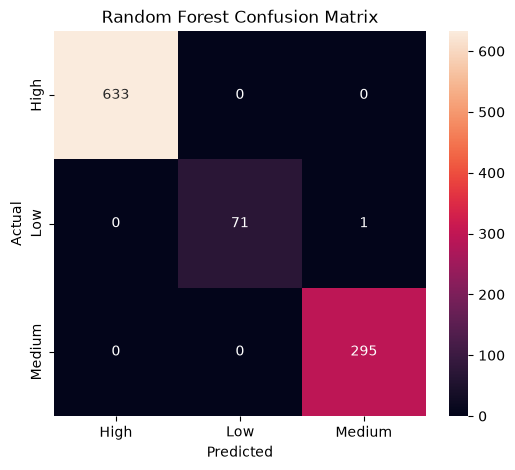

In [17]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [18]:
joblib.dump(rf_model, "cleaned_data/traffic_prediction_model.pkl")

['cleaned_data/traffic_prediction_model.pkl']

In [19]:
joblib.dump(X.columns.tolist(),
            "cleaned_data/model_features.pkl")

['cleaned_data/model_features.pkl']

In [20]:
loaded_model = joblib.load(
    "cleaned_data/traffic_prediction_model.pkl"
)

predictions = loaded_model.predict(X_test)

print(predictions[:10])

['High' 'Medium' 'High' 'Medium' 'High' 'Medium' 'High' 'Low' 'High'
 'High']


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average="weighted")
rf_recall = recall_score(y_test, y_pred_rf, average="weighted")
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
Accuracy : 0.999
Precision: 0.9990033783783784
Recall   : 0.999
F1 Score : 0.998997349520192


In [22]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [23]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average="weighted")
dt_recall = recall_score(y_test, y_pred_dt, average="weighted")
dt_f1 = f1_score(y_test, y_pred_dt, average="weighted")

print("Decision Tree")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree
Accuracy : 0.999
Precision: 0.9990033783783784
Recall   : 0.999
F1 Score : 0.998997349520192


In [24]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

C:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average="weighted")
lr_recall = recall_score(y_test, y_pred_lr, average="weighted")
lr_f1 = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression
Accuracy : 0.756
Precision: 0.7822354942557322
Recall   : 0.756
F1 Score : 0.7630233066704168


In [26]:
from xgboost import XGBClassifier

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [30]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)

In [31]:
xgb_accuracy = accuracy_score(y_test_encoded, y_pred_xgb)
xgb_precision = precision_score(
    y_test_encoded,
    y_pred_xgb,
    average="weighted"
)
xgb_recall = recall_score(
    y_test_encoded,
    y_pred_xgb,
    average="weighted"
)
xgb_f1 = f1_score(
    y_test_encoded,
    y_pred_xgb,
    average="weighted"
)

print("XGBoost")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

XGBoost
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [32]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree",
        "Logistic Regression",
        "XGBoost"
    ],
    "Accuracy": [
        rf_accuracy,
        dt_accuracy,
        lr_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        rf_precision,
        dt_precision,
        lr_precision,
        xgb_precision
    ],
    "Recall": [
        rf_recall,
        dt_recall,
        lr_recall,
        xgb_recall
    ],
    "F1 Score": [
        rf_f1,
        dt_f1,
        lr_f1,
        xgb_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.999,0.999003,0.999,0.998997
1,Decision Tree,0.999,0.999003,0.999,0.998997
2,Logistic Regression,0.756,0.782235,0.756,0.763023
3,XGBoost,1.000,1.000000,1.000,1.000000


In [33]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: XGBoost


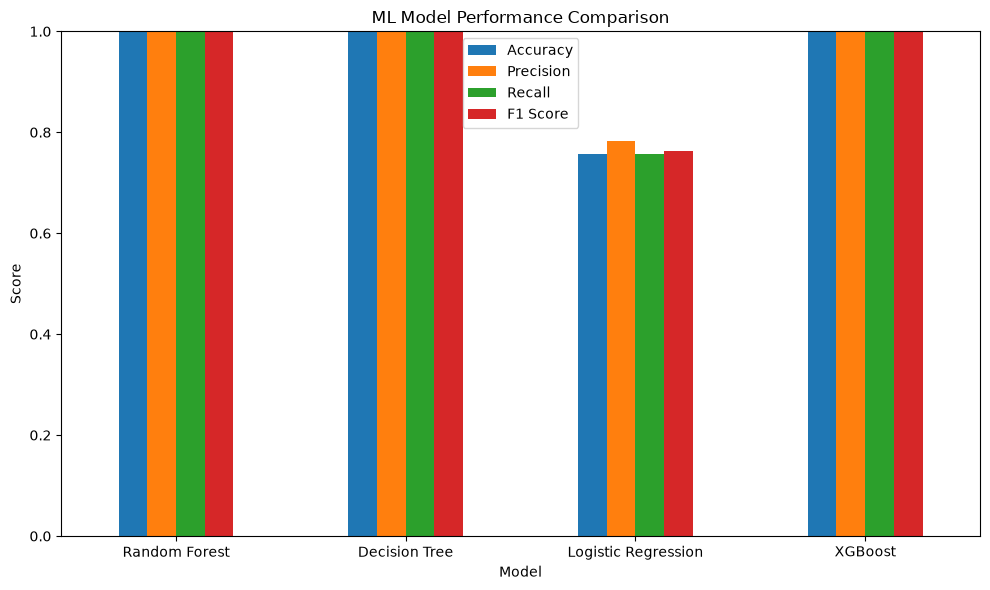

In [34]:
results.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("ML Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
joblib.dump(
    rf_model,
    "cleaned_data/traffic_prediction_model.pkl"
)

['cleaned_data/traffic_prediction_model.pkl']

In [36]:
joblib.dump(
    xgb_model,
    "cleaned_data/traffic_prediction_model.pkl"
)

['cleaned_data/traffic_prediction_model.pkl']

In [37]:
joblib.dump(
    le,
    "cleaned_data/label_encoder.pkl"
)

['cleaned_data/label_encoder.pkl']

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print("Random Forest")
print("-------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
-------------------------
Accuracy : 0.999
Precision: 0.9990033783783784
Recall   : 0.999
F1 Score : 0.998997349520192


In [39]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.999,0.999003,0.999,0.998997
1,Decision Tree,0.999,0.999003,0.999,0.998997
2,Logistic Regression,0.756,0.782235,0.756,0.763023
3,XGBoost,1.000,1.000000,1.000,1.000000


In [40]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [41]:
import joblib

if best_model_name == "Random Forest":
    final_model = rf_model

elif best_model_name == "Decision Tree":
    final_model = dt_model

elif best_model_name == "Logistic Regression":
    final_model = lr_model

elif best_model_name == "XGBoost":
    final_model = xgb_model

joblib.dump(
    final_model,
    "cleaned_data/traffic_prediction_model.pkl"
)

print("Final model saved:", best_model_name)

Final model saved: XGBoost


In [42]:
joblib.dump(
    X.columns.tolist(),
    "cleaned_data/model_features.pkl"
)

print("Feature list saved successfully.")

Feature list saved successfully.


In [43]:
loaded_model = joblib.load(
    "cleaned_data/traffic_prediction_model.pkl"
)

print("Loaded model:", type(loaded_model).__name__)

Loaded model: XGBClassifier


In [44]:
final_predictions = loaded_model.predict(X_test)

print("First 10 predictions:")
print(final_predictions[:10])

First 10 predictions:
[0 2 0 2 0 2 0 1 0 0]


In [46]:
from sklearn.metrics import accuracy_score

# Make predictions using the saved final model
final_predictions = loaded_model.predict(X_test)

# If the final model is XGBoost, convert numeric predictions
# back to the original class names
if best_model_name == "XGBoost":
    final_predictions = le.inverse_transform(
        final_predictions.astype(int)
    )

# Calculate accuracy
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

print("Final Model:", best_model_name)
print("Final Model Accuracy:", final_accuracy)

Final Model: XGBoost
Final Model Accuracy: 1.0


In [47]:
print("Actual values:")
print(y_test.iloc[:10].values)

print("\nPredicted values:")
print(final_predictions[:10])

Actual values:
<StringArray>
[  'High', 'Medium',   'High', 'Medium',   'High', 'Medium',   'High',
    'Low',   'High',   'High']
Length: 10, dtype: str

Predicted values:
['High' 'Medium' 'High' 'Medium' 'High' 'Medium' 'High' 'Low' 'High'
 'High']


In [48]:
print("Best Model:", best_model_name)
print("Loaded Model:", type(loaded_model).__name__)

Best Model: XGBoost
Loaded Model: XGBClassifier


In [49]:
print("Best Model:", best_model_name)
print("Loaded Model:", type(loaded_model).__name__)
print("Final Model Accuracy:", final_accuracy)

Best Model: XGBoost
Loaded Model: XGBClassifier
Final Model Accuracy: 1.0


In [50]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.999,0.999003,0.999,0.998997
1,Decision Tree,0.999,0.999003,0.999,0.998997
2,Logistic Regression,0.756,0.782235,0.756,0.763023
3,XGBoost,1.000,1.000000,1.000,1.000000


In [51]:
import joblib

joblib.dump(
    xgb_model,
    "cleaned_data/traffic_prediction_model.pkl"
)

joblib.dump(
    le,
    "cleaned_data/label_encoder.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "cleaned_data/model_features.pkl"
)

print("XGBoost model saved successfully.")
print("Label encoder saved successfully.")
print("Feature list saved successfully.")

XGBoost model saved successfully.
Label encoder saved successfully.
Feature list saved successfully.


In [52]:
loaded_model = joblib.load(
    "cleaned_data/traffic_prediction_model.pkl"
)

loaded_encoder = joblib.load(
    "cleaned_data/label_encoder.pkl"
)

loaded_features = joblib.load(
    "cleaned_data/model_features.pkl"
)

print("Model:", type(loaded_model).__name__)
print("Classes:", loaded_encoder.classes_)
print("Number of features:", len(loaded_features))

Model: XGBClassifier
Classes: ['High' 'Low' 'Medium']
Number of features: 20
